# Data Exploration

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_style("whitegrid")

## Load Data

In [202]:
df = pd.read_csv("../data/raw/training_set_DM.csv")

# Overview

In [203]:
df.columns

Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate'

In [204]:
df.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,4/4/2013 8:32,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,4/4/2013 8:32,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,4/4/2013 8:32,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,4/4/2013 8:32,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,4/4/2013 8:32,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [205]:
df['srch_id'].nunique()

42117

In [206]:
df.groupby('srch_id').size().describe()

count    42117.000000
mean        24.896716
std          9.095661
min          5.000000
25%         18.000000
50%         30.000000
75%         32.000000
max         37.000000
dtype: float64

# Missing Value

In [207]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing.head(20)

comp1_rate_percent_diff      98.165796
comp6_rate_percent_diff      98.083113
comp1_rate                   97.681139
comp1_inv                    97.485349
comp4_rate_percent_diff      97.348115
comp7_rate_percent_diff      97.228524
gross_bookings_usd           97.226236
comp6_rate                   95.151038
visitor_hist_starrating      94.874949
visitor_hist_adr_usd         94.856162
comp6_inv                    94.731230
comp4_rate                   93.725389
comp7_rate                   93.671602
srch_query_affinity_score    93.565076
comp4_inv                    93.009656
comp7_inv                    92.863171
comp3_rate_percent_diff      90.442744
comp2_rate_percent_diff      88.798703
comp8_rate_percent_diff      87.654388
comp5_rate_percent_diff      83.125098
dtype: float64

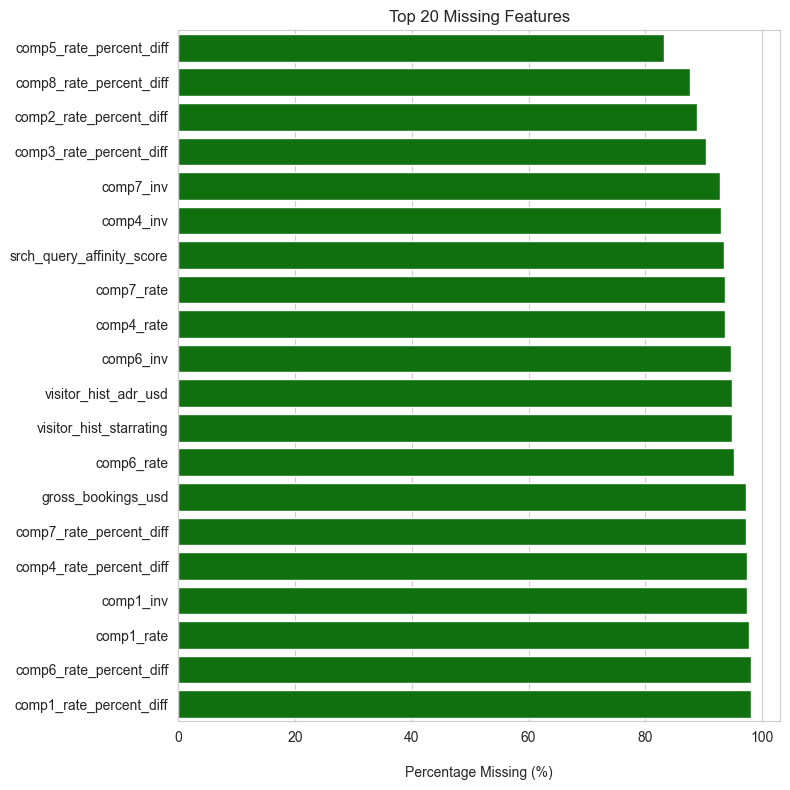

In [208]:
missing_top = missing.head(20).sort_values()

plt.figure(figsize=(8,8))
sns.barplot(
    x=missing_top.values,
    y=missing_top.index,
    color="green"   # 👈 force single color
)

plt.title("Top 20 Missing Features")
plt.xlabel("Percentage Missing (%)", labelpad=15)
plt.ylabel("")

plt.tight_layout()
plt.show()

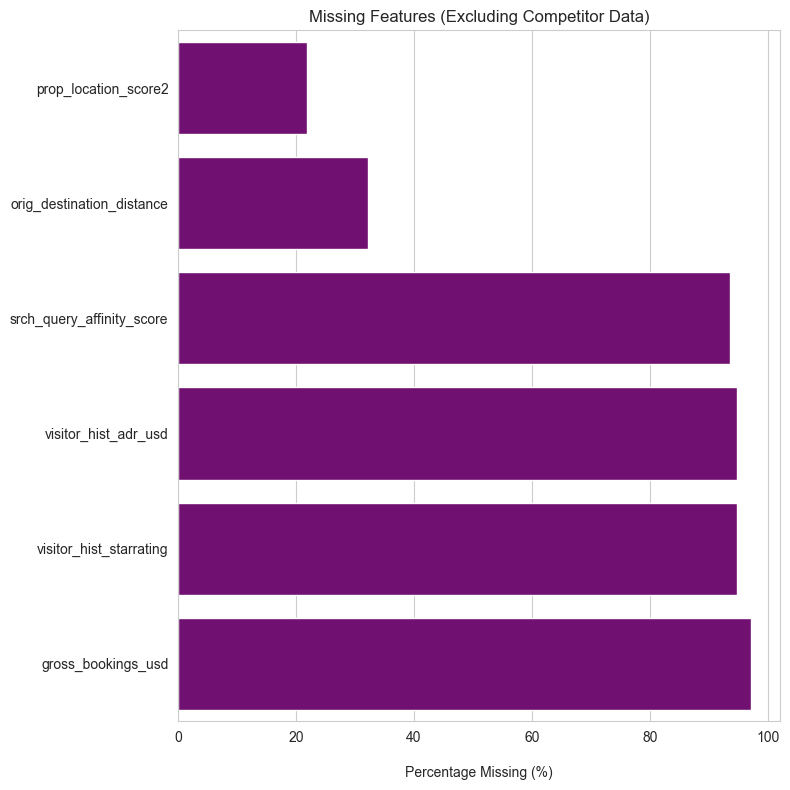

In [209]:
non_comp_missing = missing[~missing.index.str.contains("comp")]
non_comp_top = non_comp_missing.sort_values(ascending=False).head(6)
non_comp_top = non_comp_top.sort_values()

plt.figure(figsize=(8,8))
sns.barplot(
    x=non_comp_top.values,
    y=non_comp_top.index,
    color="purple"
)

plt.title("Missing Features (Excluding Competitor Data)")
plt.xlabel("Percentage Missing (%)", labelpad=15)
plt.ylabel("")

plt.tight_layout()
plt.show()

# Target Variables

In [210]:
df['booking_bool'].mean() 

0.02773764394535441

In [211]:
df['click_bool'].mean() 

0.044694943137114654

c:\Users\luizr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


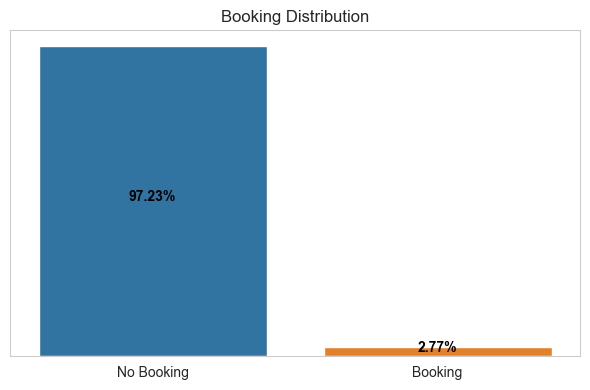

In [212]:
no_booking = 1 - df['booking_bool'].mean() 
booking = df['booking_bool'].mean() 

labels = ["No Booking", "Booking"]
values = [no_booking, booking]

plt.figure(figsize=(6,4))
bars = sns.barplot(x=labels, y=values)

plt.title("Booking Distribution")

# Add labels inside bars
for i, v in enumerate(values):
    plt.text(
        i, 
        v / 2,                          # center inside bar
        f"{v:.2%}",                     # percentage format
        ha='center', 
        color='black', 
        fontweight='bold'
    )

plt.yticks([])
plt.tight_layout()
plt.show()

c:\Users\luizr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


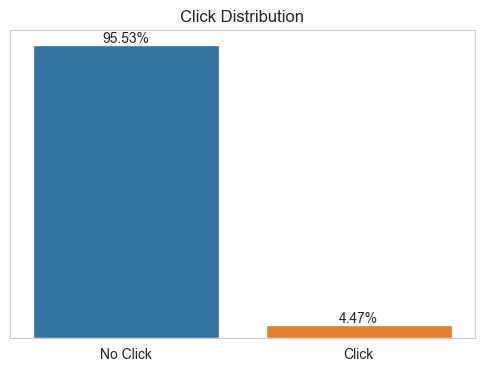

In [213]:
plt.figure(figsize=(6,4))

values = [no_click_rate, click_rate]
labels = ["No Click", "Click"]

sns.barplot(x=labels, y=values)

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.2%}", ha='center')

plt.title("Click Distribution")
plt.yticks([])
plt.show()

c:\Users\luizr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


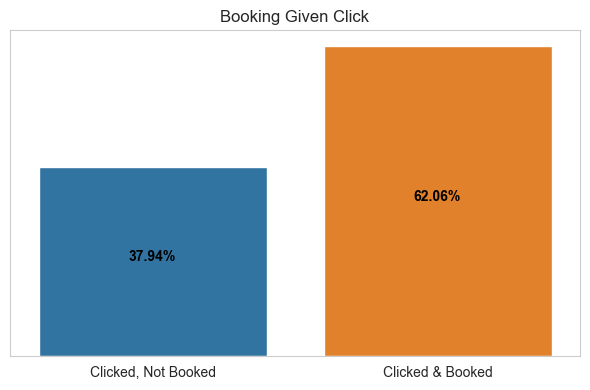

In [214]:
clicked_df = df[df['click_bool'] == 1]
booking_given_click = clicked_df['booking_bool'].mean()
no_booking_given_click = 1 - booking_given_click
labels = ["Clicked, Not Booked", "Clicked & Booked"]
values = [no_booking_given_click, booking_given_click]

plt.figure(figsize=(6,4))
bars = sns.barplot(x=labels, y=values)

plt.title("Booking Given Click")

# Add percentage labels
for i, v in enumerate(values):
    plt.text(
        i,
        v / 2,
        f"{v:.2%}",
        ha='center',
        color='black',
        fontweight='bold'
    )

plt.yticks([])
plt.tight_layout()
plt.show()

# Review Score

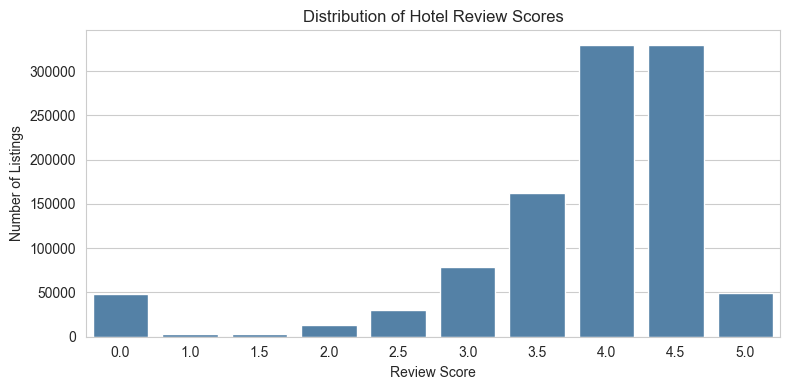

In [215]:
review_counts = df["prop_review_score"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(
    x=review_counts.index.astype(str),
    y=review_counts.values,
    color="steelblue"
)

plt.title("Distribution of Hotel Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Position bias

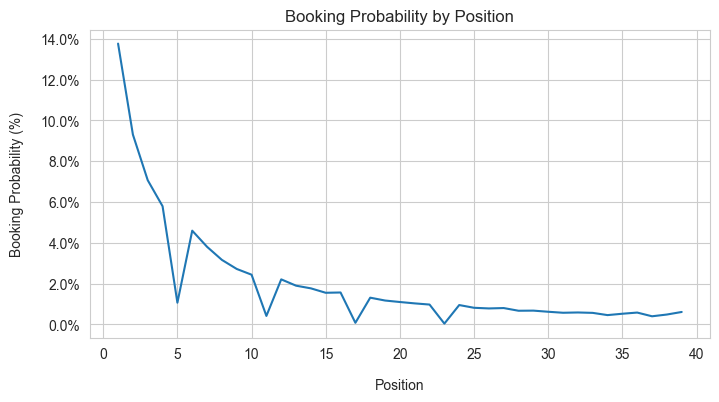

In [216]:
position_booking = df.groupby('position')['booking_bool'].mean() * 100

position_stats = df.groupby('position')['booking_bool'].agg(['mean', 'count'])
position_stats['mean'] = position_stats['mean'] * 100

# keep only positions with enough samples
position_stats = position_stats[position_stats['count'] > 100]

plt.figure(figsize=(8,4))
plt.plot(position_stats.index, position_stats['mean'])

plt.title("Booking Probability by Position")
plt.xlabel("Position", labelpad=12)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.ylabel("Booking Probability (%)", labelpad=12)

plt.show()

# Price Distribution

c:\Users\luizr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


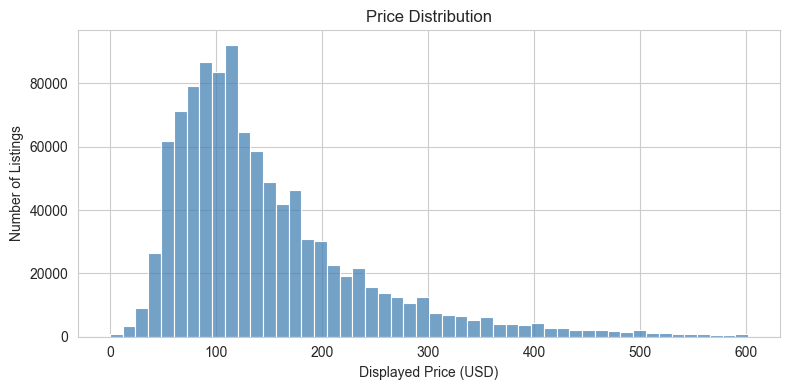

In [217]:
price_filtered = df[df["price_usd"] < df["price_usd"].quantile(0.99)]

plt.figure(figsize=(8,4))
sns.histplot(price_filtered["price_usd"], bins=50, color="steelblue")

plt.title("Price Distribution")
plt.xlabel("Displayed Price (USD)")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

c:\Users\luizr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


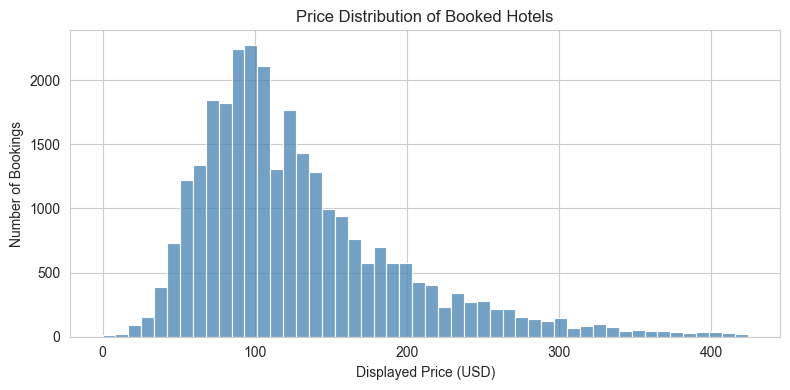

In [218]:
booked_df = df[df["booking_bool"] == 1]
booked_price_filtered = booked_df[
    booked_df["price_usd"] < booked_df["price_usd"].quantile(0.99)
]

plt.figure(figsize=(8,4))
sns.histplot(booked_price_filtered["price_usd"], bins=50, color="steelblue")

plt.title("Price Distribution of Booked Hotels")
plt.xlabel("Displayed Price (USD)")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()

# Hotels per search

c:\Users\luizr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


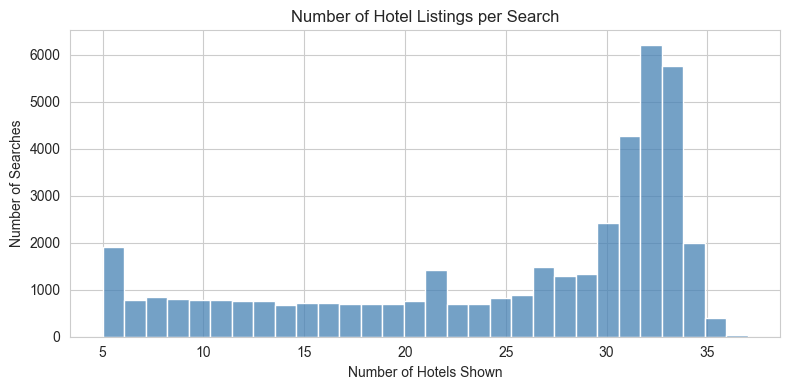

In [219]:
hotels_per_search = df.groupby("srch_id").size()

plt.figure(figsize=(8,4))
sns.histplot(hotels_per_search, bins=30, color="steelblue")

plt.title("Number of Hotel Listings per Search")
plt.xlabel("Number of Hotels Shown")
plt.ylabel("Number of Searches")

plt.tight_layout()
plt.show()

# Competitors

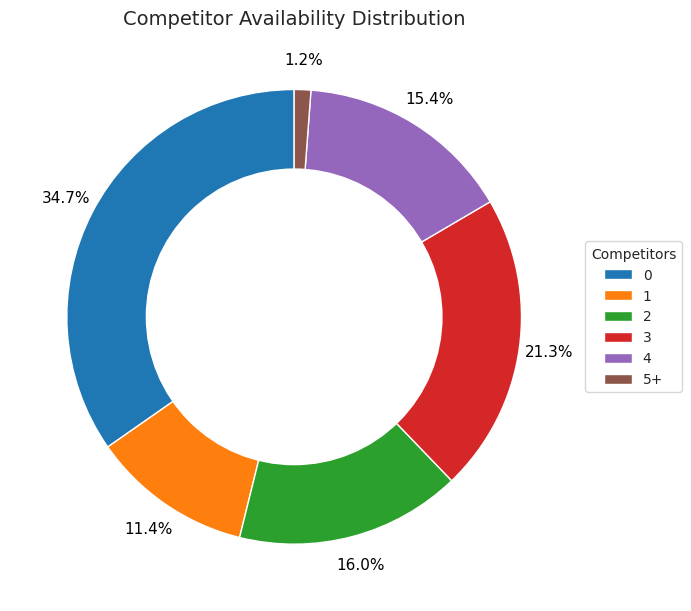

In [220]:
plt.rcParams["font.family"] = "DejaVu Sans"

plt.figure(figsize=(7,7))

wedges, _, autotexts = plt.pie(
    comp_counts.values,
    labels=None,                
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=1.13           
)

centre_circle = plt.Circle((0, 0), 0.65, fc="white")
plt.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color("black")   

plt.legend(
    wedges,
    comp_counts.index,
    title="Competitors",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Competitor Availability Distribution", fontsize=14)
plt.tight_layout()
plt.show()

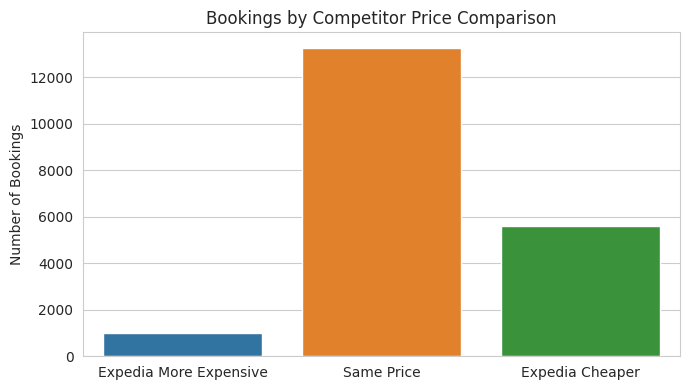

In [221]:
comp_rate_cols = [
    col for col in df.columns
    if col.startswith("comp") and col.endswith("_rate")
]

df["expedia_vs_competitors"] = df[comp_rate_cols].max(axis=1)

comparison_labels = {
    -1.0: "Expedia More Expensive",
     0.0: "Same Price",
     1.0: "Expedia Cheaper"
}

plot_df = df[df["booking_bool"] == 1].copy()
plot_df["price_comparison"] = plot_df["expedia_vs_competitors"].map(comparison_labels)

order = ["Expedia More Expensive", "Same Price", "Expedia Cheaper"]

plt.figure(figsize=(7,4))
sns.countplot(
    data=plot_df,
    x="price_comparison",
    order=order
)

plt.title("Bookings by Competitor Price Comparison")
plt.xlabel("")
plt.ylabel("Number of Bookings")


plt.tight_layout()
plt.show()

# Data Statistics

In [222]:
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])
print("Unique searches:", df['srch_id'].nunique())

hotels_per_search = df.groupby('srch_id').size()

print("Avg hotels per search:", hotels_per_search.mean())
print("Min hotels per search:", hotels_per_search.min())
print("Max hotels per search:", hotels_per_search.max())

Number of rows: 1048575
Number of columns: 55
Unique searches: 42117
Avg hotels per search: 24.89671629033407
Min hotels per search: 5
Max hotels per search: 37
